## Outlier Target Selection (MIA Paper §4.3)

Selection criterion from the paper:

> *"records that either have rare categorical attribute values or numerical values outside the attribute's 95% quantile"*

**Selection pipeline:**

1. **Numerical columns** — Flag records above the 95th percentile; score by relative excess
2. **Categorical columns** — Flag records with rare values (frequency < 1%); score by inverse frequency
3. **Score matrix** — Combine all column scores into a single matrix
4. **Diversity selection** — Define thematic column groups; pick the top-scoring record per group

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Parameters ─────────────────────────────────
DATA_DIR = "../data/adult"
QUANTILE        = 0.95   # percentile threshold for numerical outliers
RARE_THRESHOLD  = 0.01   # frequency threshold for rare categorical values
EXCLUDE_COLS    = ["label", "fnlwgt"]   # columns excluded from scoring
N_TARGETS       = 5      # number of outlier records to select

# ── Data loading ───────────────────────────────
# Assign sequential IDs compatible with SDR's load_local_data_as_df
df_raw = pd.read_csv(f"{DATA_DIR}.csv")
df_raw["ID"] = [f"ID{i}" for i in range(len(df_raw))]
df = df_raw.set_index("ID")

# ── Column type classification ──────────────────
feat_cols = [c for c in df.columns if c not in EXCLUDE_COLS]
num_cols  = [c for c in feat_cols if pd.api.types.is_numeric_dtype(df[c])]
cat_cols  = [c for c in feat_cols if c not in num_cols]

print(f"Feature columns: {len(feat_cols)}")
print(f"  Numerical  : {num_cols}")
print(f"  Categorical: {cat_cols}")

Feature columns: 13
  Numerical  : ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
  Categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


### Step 1 — Numerical columns: scoring by 95th-percentile excess

- **Criterion**: value > p95
- **Score**: `(value − p95) / p95`  (relative excess; columns with p95 = 0 use `value / max`)

In [2]:
num_scores = pd.DataFrame(0.0, index=df.index, columns=num_cols)
num_thresholds = {}

for col in num_cols:
    p95 = df[col].quantile(QUANTILE)
    num_thresholds[col] = p95
    if p95 > 0:
        num_scores[col] = ((df[col] - p95) / p95).clip(lower=0)
    else:
        max_val = df[col].max()
        if max_val > 0:
            num_scores[col] = (df[col] / max_val).clip(lower=0)

# p95 threshold and number of records above it per column
summary = pd.DataFrame({
    "p95": num_thresholds,
    "# records above p95": (num_scores > 0).sum(),
    "max score": num_scores.max().round(3),
    "top record ID": num_scores.idxmax(),
}).rename_axis("column")

display(summary)

# Top 10 records by total score across all numerical columns
top_num = num_scores[num_scores.any(axis=1)].copy()
top_num["total score"] = top_num.sum(axis=1)
display(top_num.sort_values("total score", ascending=False).head(10).round(3))

,p95,# records above p95,max score,top record ID
column,,,,
age,63.0,1544,0.429,ID222
education-num,14.0,989,0.143,ID20
capital-gain,5013.0,1579,18.948,ID1246
capital-loss,0.0,1519,1.000,ID8963
hours-per-week,60.0,1110,0.650,ID935


,age,education-num,capital-gain,capital-loss,hours-per-week,total score
ID,,,,,,
ID16422,0.000,0.071,18.948,0.0,0.333,19.353
ID6524,0.000,0.000,18.948,0.0,0.333,19.281
ID20283,0.000,0.000,18.948,0.0,0.333,19.281
ID23467,0.000,0.000,18.948,0.0,0.333,19.281
ID26825,0.000,0.143,18.948,0.0,0.167,19.257
ID10964,0.000,0.143,18.948,0.0,0.167,19.257
ID16740,0.000,0.143,18.948,0.0,0.167,19.257
ID24983,0.000,0.000,18.948,0.0,0.250,19.198
ID18463,0.175,0.071,18.948,0.0,0.000,19.194


### Step 2 — Categorical columns: scoring by rarity

- **Criterion**: value frequency < `RARE_THRESHOLD` (default 1%)
- **Score**: `1 / frequency`  (rarer values score higher)

In [3]:
cat_scores = pd.DataFrame(0.0, index=df.index, columns=cat_cols)
cat_rare_vals = {}

for col in cat_cols:
    freq = df[col].value_counts(normalize=True)
    rare_vals = freq[freq < RARE_THRESHOLD]
    cat_rare_vals[col] = rare_vals
    freq_series = df[col].map(freq.to_dict()).astype(float)
    cat_scores[col] = np.where(
        freq_series < RARE_THRESHOLD,
        1.0 / freq_series.clip(lower=1e-10),
        0.0,
    )

# Summary table of rare values
rare_summary_rows = []
for col, rare_vals in cat_rare_vals.items():
    for val, freq in rare_vals.items():
        rare_summary_rows.append({
            "column": col, "rare value": val,
            "frequency (%)": round(freq * 100, 3),
            "# records": round(freq * len(df)),
            "score": round(1.0 / freq, 1),
        })

rare_df = pd.DataFrame(rare_summary_rows).sort_values("frequency (%)").reset_index(drop=True)
display(rare_df)

,column,rare value,frequency (%),# records,score
0,native-country,Holand-Netherlands,0.003,1,32561.0
1,workclass,Never-worked,0.021,7,4651.6
2,occupation,Armed-Forces,0.028,9,3617.9
3,native-country,Scotland,0.037,12,2713.4
4,native-country,Honduras,0.040,13,2504.7
5,native-country,Hungary,0.040,13,2504.7
6,workclass,Without-pay,0.043,14,2325.8
7,native-country,Outlying-US(Guam-USVI-etc),0.043,14,2325.8
8,native-country,Yugoslavia,0.049,16,2035.1
9,native-country,Laos,0.055,18,1808.9


### Step 3 — Combined score matrix

Merge numerical and categorical scores into one matrix. Records with at least one non-zero score are **outlier candidates**.

> **Note:** The *total score* shown below (sum across all columns) is used **only for display** — to surface the most notable candidates visually.
> The actual selection in Steps 4–5 uses the **per-group maximum score**, not the total, so that records extreme in *one* dimension are preferred over records that are slightly above average in many dimensions.

In [4]:
scores_raw = pd.concat([num_scores, cat_scores], axis=1)[feat_cols]

# Normalize each column to [0, 1] by dividing by its maximum score
# → unifies numerical scores (~19) and categorical scores (~32561) onto the same scale
col_max = scores_raw.max()
scores_norm = scores_raw.div(col_max.where(col_max > 0, 1.0))

# Tiebreaker: add a tiny fraction of the raw score so that when two records
# share the same normalized score, the one with higher raw rarity wins
global_max = scores_raw.max().max()
scores = scores_norm + scores_raw * (1e-6 / global_max) if global_max > 0 else scores_norm

is_candidate = scores.gt(0).any(axis=1)
candidates = scores[is_candidate].copy()
candidates["total score"] = candidates[feat_cols].sum(axis=1)

print(f"Outlier candidates: {is_candidate.sum()} / {len(df)} records")

# Top 15 candidates (display with [0,1] normalized scores)
display(
    scores_norm[is_candidate]
    .assign(**{"total score": candidates["total score"]})
    .sort_values("total score", ascending=False)
    .head(15)
    .round(3)
    .style.background_gradient(cmap="YlOrRd", axis=0, subset=feat_cols)
)

Outlier candidates: 8338 / 32561 records


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,total score
ID,,,,,,,,,,,,,,
ID28264,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.256000,0.010000,2.766000
ID8710,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.128000,0.000000,2.628000
ID25831,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.454000,1.000000,0.000000,2.454000
ID32432,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.308000,0.000000,2.308000
ID16740,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.256000,0.000000,2.256000
ID10964,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.256000,0.000000,2.256000
ID26825,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.256000,0.000000,2.256000
ID12600,0.407000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.846000,0.000000,0.000000,2.253000
ID15279,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.128000,0.000000,2.128000


### Step 4 — Column groups and per-group top candidates

Group columns by theme and inspect the top-scoring record per group.
This ensures **one record per outlier type** is selected (diversity).

In [5]:
col_groups = {
    "financial":   ["capital-gain", "capital-loss"],
    "work":        ["hours-per-week", "workclass", "occupation"],
    "demographic": ["age", "race", "native-country"],
    "education":   ["education", "education-num"],
    "family":      ["marital-status", "relationship"],
}

# Inspect the top-scoring record per group
remaining = scores[is_candidate].copy()

group_preview_rows = []
for group, cols in col_groups.items():
    valid_cols = [c for c in cols if c in remaining.columns]
    group_score = remaining[valid_cols].max(axis=1)
    best_id = group_score.idxmax()
    best_score = group_score.max()
    best_col = remaining.loc[best_id, valid_cols].idxmax()
    best_val = df.loc[best_id, best_col]
    group_preview_rows.append({
        "group": group,
        "primary column": best_col,
        "candidate ID": best_id,
        "value": best_val,
        "score": round(best_score, 3),
    })

display(pd.DataFrame(group_preview_rows).set_index("group"))

,primary column,candidate ID,value,score
group,,,,
financial,capital-gain,ID1246,99999,1.0
work,workclass,ID5361,Never-worked,1.0
demographic,native-country,ID19609,Holand-Netherlands,1.0
education,education,ID224,Preschool,1.0
family,marital-status,ID37,Married-AF-spouse,1.0


### Step 5 — Final selection: one record per group

Process groups ordered by fewest outlier candidates (rarest first) and pick the top-scoring record from each.
Already-selected records are removed from the pool before the next group is processed.

In [6]:
remaining = scores[is_candidate].copy()
selected_ids = []
result_rows  = []

# After normalization all groups have max score ≈ 1.0, so sort by
# number of outlier candidates in the group (fewer = rarer = higher priority)
def group_candidate_count(g):
    cols = [c for c in col_groups[g] if c in remaining.columns]
    return (remaining[cols] > 0).any(axis=1).sum()

sorted_groups = sorted(col_groups, key=group_candidate_count)

for group in sorted_groups:
    if len(selected_ids) >= N_TARGETS:
        break
    valid_cols  = [c for c in col_groups[group] if c in remaining.columns]
    group_score = remaining[valid_cols].max(axis=1)
    if group_score.max() == 0:
        continue

    best_id  = group_score.idxmax()
    rec      = scores.loc[best_id]
    outlier_cols = rec[rec > 0].index.tolist()
    primary_col  = rec.idxmax()

    selected_ids.append(best_id)
    remaining = remaining.drop(best_id)  # remove selected record from pool

    result_rows.append({
        "group":           group,
        "selected ID":     best_id,
        "primary column":  primary_col,
        "value":           df.loc[best_id, primary_col],
        "norm. score":     round(rec[primary_col], 3),
        "outlier columns": ", ".join(outlier_cols),
    })

result_df = pd.DataFrame(result_rows).set_index("group")
display(result_df)

print("\nSelected IDs:", str(selected_ids).replace("'", '"'))

,selected ID,primary column,value,norm. score,outlier columns
group,,,,,
family,ID37,marital-status,Married-AF-spouse,1.0,marital-status
education,ID224,education,Preschool,1.0,education
work,ID5361,workclass,Never-worked,1.0,workclass
financial,ID1246,capital-gain,99999,1.0,"education-num, capital-gain"
demographic,ID19609,native-country,Holand-Netherlands,1.0,"capital-loss, native-country"



Selected IDs: ["ID37", "ID224", "ID5361", "ID1246", "ID19609"]


In [7]:
# Inspect the raw data of selected records
display(df.loc[selected_ids])

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,label
ID,,,,,,,,,,,,,,,
ID37,19,Private,544091,HS-grad,9,Married-AF-spouse,Adm-clerical,Wife,White,Female,0,0,25,United-States,<=50K
ID224,53,Local-gov,140359,Preschool,1,Never-married,Machine-op-inspct,Not-in-family,White,Female,0,0,35,United-States,<=50K
ID5361,18,Never-worked,206359,10th,6,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K
ID1246,54,Self-emp-inc,166459,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999,0,60,United-States,>50K
ID19609,32,Private,27882,Some-college,10,Never-married,Machine-op-inspct,Other-relative,White,Female,0,2205,40,Holand-Netherlands,<=50K


# Distribution of each column

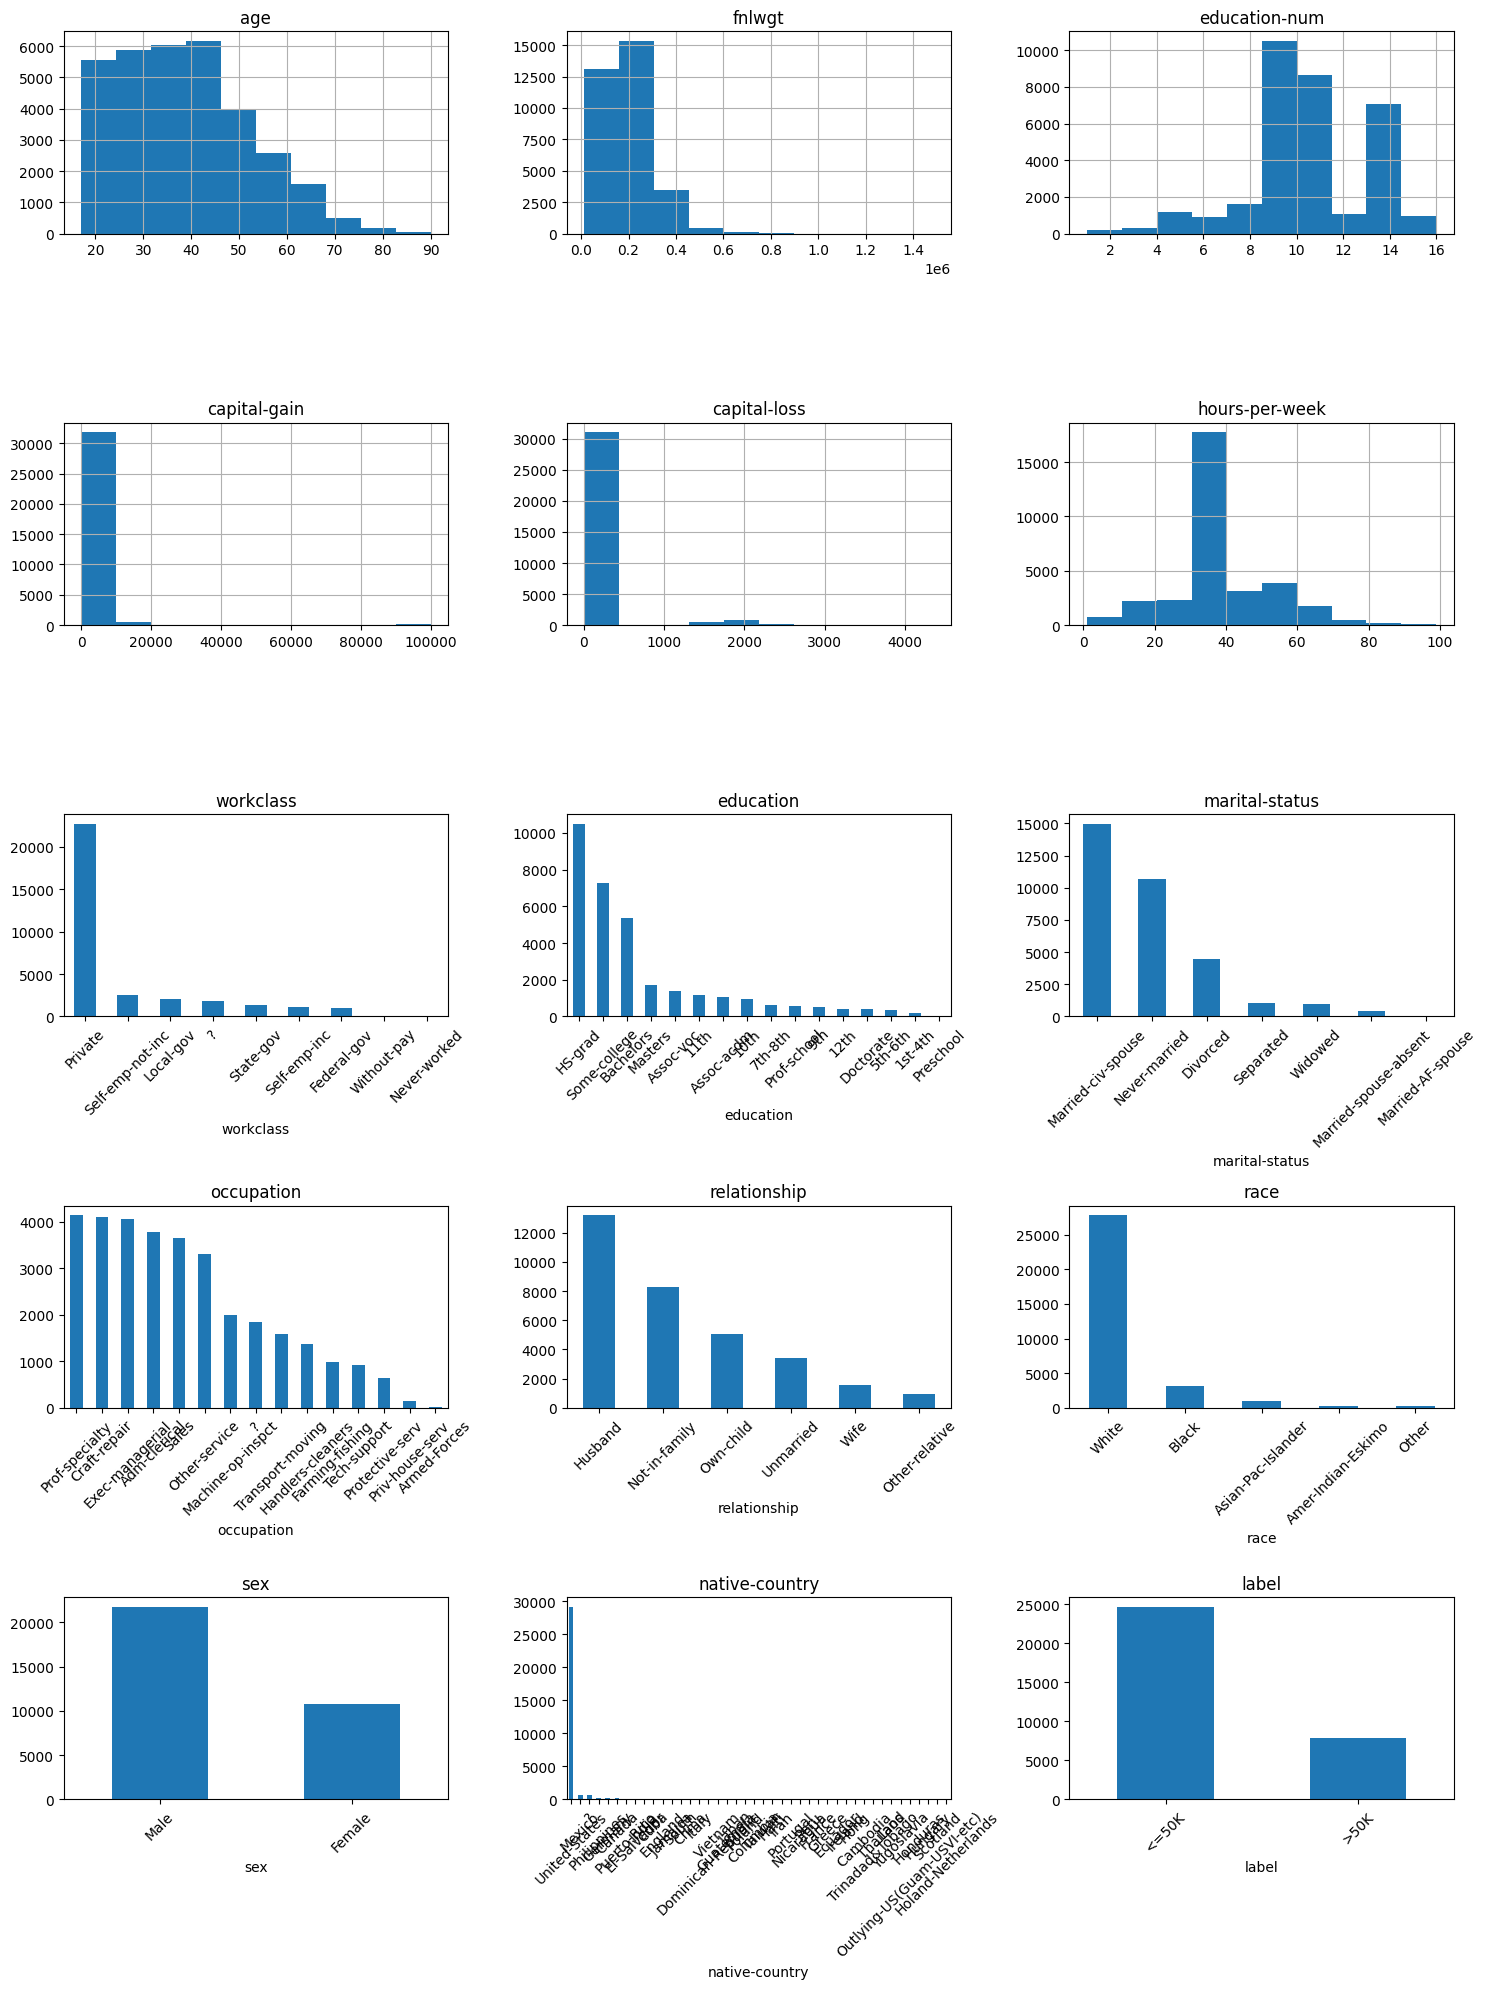

In [8]:
df = pd.read_csv(f"{DATA_DIR}.csv")

# Convert object columns to category
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='category').columns.tolist()

all_cols = numeric_cols + categorical_cols
n = len(all_cols)

fig, axes = plt.subplots(
    nrows=(n + 2) // 3,
    ncols=3,
    figsize=(15, 4 * ((n + 2) // 3))
)
axes = axes.flatten()

# Numeric columns → histogram
for ax, col in zip(axes, numeric_cols):
    df[col].hist(bins=10, ax=ax)
    ax.set_title(col)

# Categorical columns → bar chart
for ax, col in zip(axes[len(numeric_cols):], categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

# Hide unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()